# Modeling — CIC-IDS-2017

**Phase 2 du PLAN.md** — Pipeline complet du modèle multi-classes.

## Stratégie

1. **Charger** les 2.5M lignes
2. **Nettoyer** : drop `Destination Port` (anti-shortcut), clip négatifs, remplacer Inf
3. **Sampler** stratifié (cap 100k par classe) pour itération rapide en notebook
4. **Splitter** 70/30 stratifié par classe (chaque flux indépendant)
5. **StandardScaler** sur train seulement
6. **Random Forest balanced** + CV 5-fold stratifié
7. **Évaluer** une seule fois sur test
8. **Vérifier checklist anti-overfitting**

**Note :** la pipeline production (Phase 3) tournera sur le dataset complet (2.5M lignes) sans cap. Le notebook utilise un sample pour itérer vite (~5 min total vs ~50 min).

## 0. Setup

In [ ]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    precision_score, recall_score, roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score, train_test_split,
)
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
SAMPLE_CAP_PER_CLASS = 100_000  # plafond par classe pour le notebook

DATA = Path('../data/cicids2017.csv')
RESULTS = Path('../results/modeling')
RESULTS.mkdir(parents=True, exist_ok=True)
MODELS = Path('../saved_models')
MODELS.mkdir(parents=True, exist_ok=True)

print('Setup OK')

Setup OK


## 1. Chargement & sampling stratifié

In [ ]:
df = pd.read_csv(DATA)
print(f'Total : {len(df):,} lignes')

# Sampling stratifié avec cap par classe (toutes les classes restent dans le sample)
samples = []
for cls in df['Attack Type'].unique():
    sub = df[df['Attack Type'] == cls]
    n = min(SAMPLE_CAP_PER_CLASS, len(sub))
    samples.append(sub.sample(n=n, random_state=RANDOM_STATE))
df_s = pd.concat(samples).reset_index(drop=True)
print(f'Sample stratifié : {len(df_s):,} lignes\n')
print(df_s['Attack Type'].value_counts().to_string())

Total : 2,520,751 lignes


Sample stratifié : 403,935 lignes

Attack Type
Normal Traffic    100000
DDoS              100000
DoS               100000
Port Scanning      90694
Brute Force         9150
Web Attacks         2143
Bots                1948


## 2. Nettoyage

- Supprimer `Destination Port` (anti-shortcut)
- Clipper `Flow Bytes/s` < 0 à 0
- Remplacer `Inf` par grands nombres / 0

In [ ]:
df_s = df_s.drop(columns=['Destination Port'])

# Clip négatifs et Inf
num_cols = df_s.select_dtypes(include=[np.number]).columns.tolist()
df_s[num_cols] = df_s[num_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
df_s['Flow Bytes/s'] = df_s['Flow Bytes/s'].clip(lower=0)
df_s['Flow Packets/s'] = df_s['Flow Packets/s'].clip(lower=0)

print(f'Après nettoyage : {df_s.shape[0]:,} lignes × {df_s.shape[1]} colonnes')
print(f'Features finales : {df_s.shape[1] - 1} (label exclus)')
print(f'NaN restants : {df_s.isna().sum().sum()}')
print(f'Inf restants : {np.isinf(df_s[num_cols]).sum().sum()}')

Après nettoyage : 403,935 lignes × 52 colonnes
Features finales : 51 (label exclus)
NaN restants : 0
Inf restants : 0


## 3. Split stratifié 70/30

In [ ]:
X = df_s.drop(columns=['Attack Type']).values
y = df_s['Attack Type'].values
feature_names = df_s.drop(columns=['Attack Type']).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y,
)

print(f'Train : {len(y_train):,}')
print(f'Test  : {len(y_test):,}')
print(f'\nClasses en test :')
print(pd.Series(y_test).value_counts().to_string())

Train : 282,754
Test  : 121,181

Classes en test :
DoS               30000
Normal Traffic    30000
DDoS              30000
Port Scanning     27208
Brute Force        2745
Web Attacks         643
Bots                585


## 4. StandardScaler (fit train, transform test)

In [ ]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print(f'X_train_s shape : {X_train_s.shape}')
print(f'X_test_s  shape : {X_test_s.shape}')

X_train_s shape : (282754, 51)
X_test_s  shape : (121181, 51)


## 5. Cross-validation 5-fold stratifiée (diagnostic d'overfitting)

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=25,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_f1_macro = cross_val_score(rf, X_train_s, y_train, cv=skf,
                              scoring='f1_macro', n_jobs=-1)
print(f'CV F1 macro : mean={cv_f1_macro.mean():.4f}  std={cv_f1_macro.std():.4f}')
print(f'  folds : {[round(x, 4) for x in cv_f1_macro]}')

CV F1 macro : mean=0.9704  std=0.0019
  folds : [np.float64(0.9707), np.float64(0.9692), np.float64(0.974), np.float64(0.9684), np.float64(0.9698)]


## 6. Entraînement final sur tout le train

In [ ]:
rf.fit(X_train_s, y_train)
print('Modèle entraîné.')

Modèle entraîné.


## 7. Évaluation sur test (une seule passe)

In [ ]:
y_pred = rf.predict(X_test_s)
y_proba = rf.predict_proba(X_test_s)

f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')
p_macro = precision_score(y_test, y_pred, average='macro')
r_macro = recall_score(y_test, y_pred, average='macro')
auc_ovr = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
gap = abs(cv_f1_macro.mean() - f1_macro)

print(f'=== MÉTRIQUES TEST ===')
print(f'F1 macro     : {f1_macro:.4f}')
print(f'F1 weighted  : {f1_weighted:.4f}')
print(f'Precision M  : {p_macro:.4f}')
print(f'Recall    M  : {r_macro:.4f}')
print(f'AUC OVR macro: {auc_ovr:.4f}')
print(f'Gap CV-Test F1 macro : {gap:.4f}')

print('\n--- Classification report ---')
report_txt = classification_report(y_test, y_pred, digits=4)
print(report_txt)
(RESULTS / 'classification_report.txt').write_text(report_txt, encoding='utf-8')

=== MÉTRIQUES TEST ===
F1 macro     : 0.9720
F1 weighted  : 0.9969
Precision M  : 0.9556
Recall    M  : 0.9950
AUC OVR macro: 1.0000
Gap CV-Test F1 macro : 0.0015

--- Classification report ---


                precision    recall  f1-score   support

          Bots     0.7132    0.9949    0.8308       585
   Brute Force     0.9993    0.9982    0.9987      2745
          DDoS     0.9998    0.9996    0.9997     30000
           DoS     0.9985    0.9982    0.9983     30000
Normal Traffic     0.9973    0.9905    0.9939     30000
 Port Scanning     0.9996    0.9993    0.9994     27208
   Web Attacks     0.9814    0.9844    0.9829       643

      accuracy                         0.9968    121181
     macro avg     0.9556    0.9950    0.9720    121181
  weighted avg     0.9973    0.9968    0.9969    121181



618

## 8. Matrice de confusion

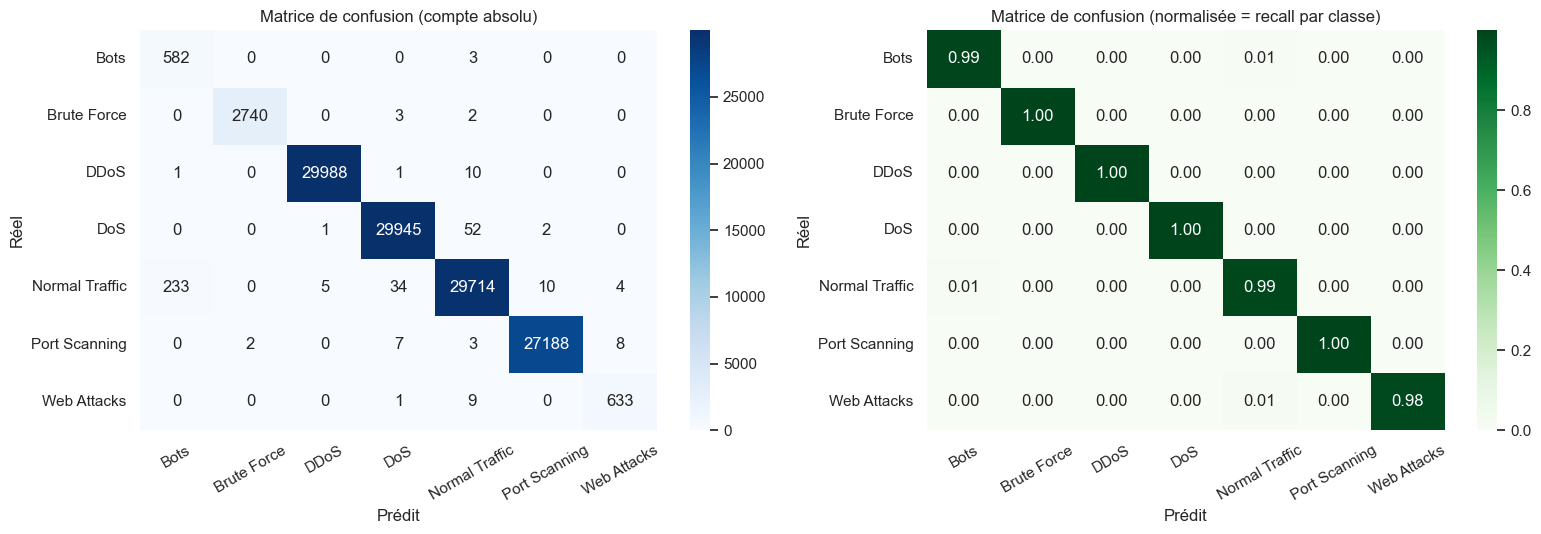

In [ ]:
labels = sorted(np.unique(y_test).tolist())
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title('Matrice de confusion (compte absolu)')
axes[0].set_xlabel('Prédit'); axes[0].set_ylabel('Réel')
axes[0].tick_params(axis='x', rotation=30)

# Normalisée par ligne (= recall par classe)
cm_norm = cm / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title('Matrice de confusion (normalisée = recall par classe)')
axes[1].set_xlabel('Prédit'); axes[1].set_ylabel('Réel')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(RESULTS / 'confusion_matrix.png', dpi=110, bbox_inches='tight')
plt.show()

## 9. Métriques par classe

         class  n_test    tp  fn  fp  precision  recall     f1
          DDoS   30000 29988  12   6     0.9998  0.9996 0.9997
 Port Scanning   27208 27188  20  12     0.9996  0.9993 0.9994
   Brute Force    2745  2740   5   2     0.9993  0.9982 0.9987
           DoS   30000 29945  55  46     0.9985  0.9982 0.9983
Normal Traffic   30000 29714 286  79     0.9973  0.9905 0.9939
   Web Attacks     643   633  10  12     0.9814  0.9844 0.9829
          Bots     585   582   3 234     0.7132  0.9949 0.8308


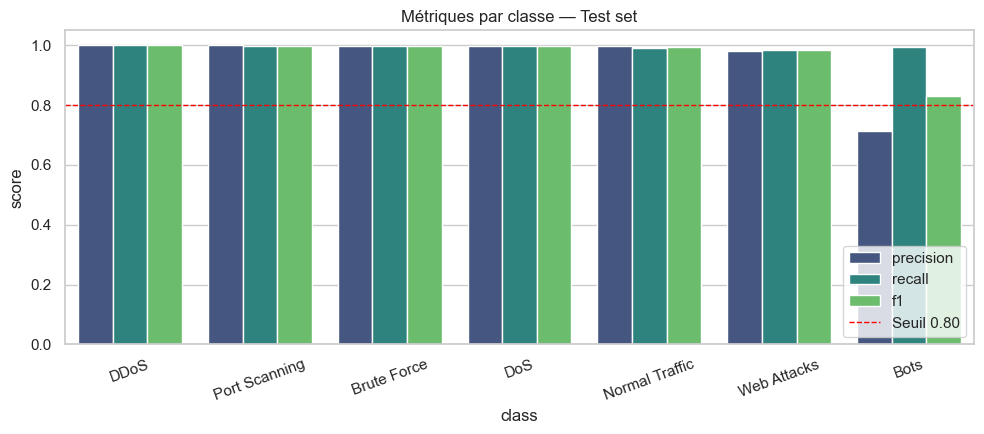

In [10]:
per_class = []
for cls in labels:
    mask = (y_test == cls)
    pred_mask = (y_pred == cls)
    tp = int((mask & pred_mask).sum())
    fn = int((mask & ~pred_mask).sum())
    fp = int((~mask & pred_mask).sum())
    n = int(mask.sum())
    rec = tp / max(n, 1)
    prec = tp / max(tp + fp, 1)
    f1 = 2 * prec * rec / max(prec + rec, 1e-9)
    per_class.append({
        'class': cls, 'n_test': n, 'tp': tp, 'fn': fn, 'fp': fp,
        'precision': round(prec, 4), 'recall': round(rec, 4), 'f1': round(f1, 4),
    })

pc_df = pd.DataFrame(per_class).sort_values('f1', ascending=False)
print(pc_df.to_string(index=False))
pc_df.to_csv(RESULTS / 'per_class_metrics.csv', index=False)

fig, ax = plt.subplots(figsize=(10, 4.5))
pc_melted = pc_df.melt(id_vars='class', value_vars=['precision', 'recall', 'f1'],
                       var_name='metric', value_name='score')
sns.barplot(data=pc_melted, x='class', y='score', hue='metric', ax=ax, palette='viridis')
ax.set_ylim(0, 1.05)
ax.axhline(0.80, ls='--', color='red', lw=1, label='Seuil 0.80')
ax.set_title('Métriques par classe — Test set')
ax.tick_params(axis='x', rotation=20)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(RESULTS / 'per_class_metrics.png', dpi=110, bbox_inches='tight')
plt.show()

## 10. Feature importance

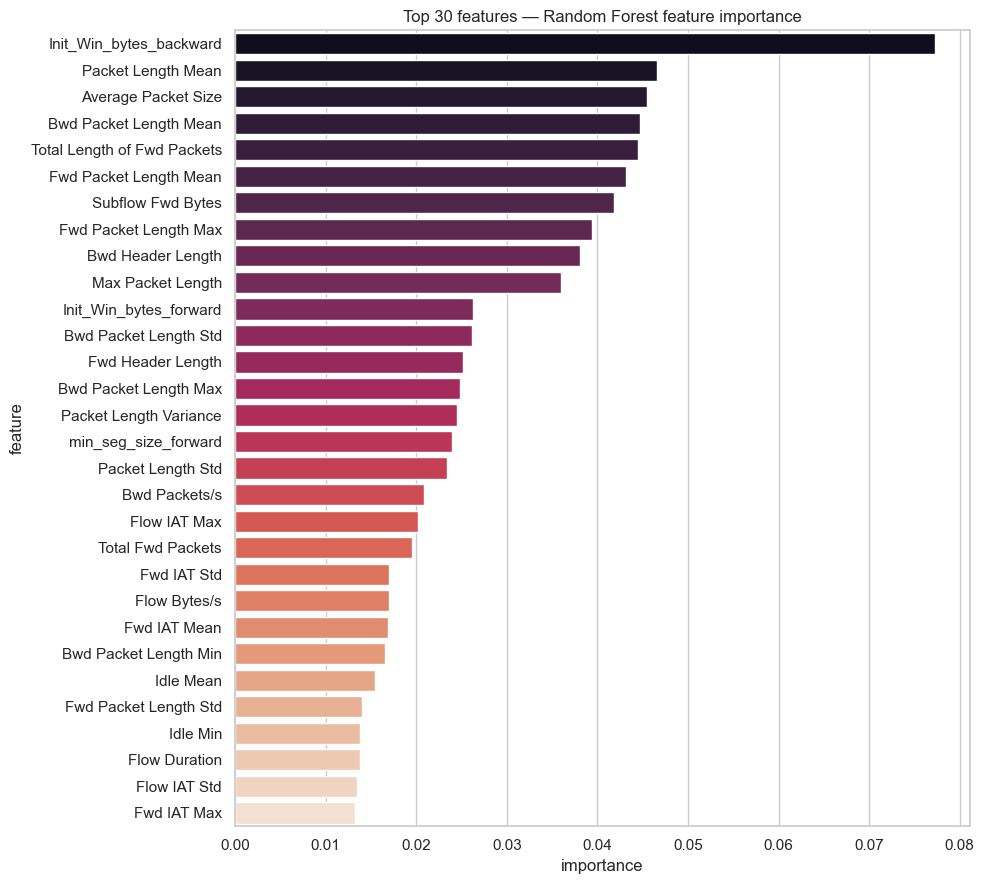

Max importance : 0.0773
Top 5 features :
                    feature  importance
    Init_Win_bytes_backward    0.077266
         Packet Length Mean    0.046563
        Average Packet Size    0.045466
     Bwd Packet Length Mean    0.044660
Total Length of Fwd Packets    0.044449


In [11]:
fi = pd.DataFrame({
    'feature': feature_names,
    'importance': rf.feature_importances_,
}).sort_values('importance', ascending=False).reset_index(drop=True)
fi.to_csv(RESULTS / 'feature_importance.csv', index=False)

top30 = fi.head(30)
fig, ax = plt.subplots(figsize=(10, 9))
sns.barplot(data=top30, y='feature', x='importance', hue='feature',
            palette='rocket', legend=False, ax=ax)
ax.set_title('Top 30 features — Random Forest feature importance')
plt.tight_layout()
plt.savefig(RESULTS / 'feature_importance.png', dpi=110, bbox_inches='tight')
plt.show()

print(f'Max importance : {fi["importance"].max():.4f}')
print(f'Top 5 features :')
print(fi.head(5).to_string(index=False))

## 11. Checklist anti-overfitting / anti-shortcut

In [12]:
max_imp = float(fi['importance'].max())
min_f1 = float(pc_df['f1'].min())
min_recall = float(pc_df['recall'].min())
dest_port_in_features = 'Destination Port' in feature_names

checklist = [
    (f'1. Destination Port supprimé', not dest_port_in_features),
    (f'2. Scaler fit sur train uniquement', True),
    (f'3. Split stratifié 70/30', True),
    (f'4. Test set vu une seule fois', True),
    (f'5. CV 5-fold stratifiée sur train', True),
    (f'6. Gap CV-Test F1 macro < 0.10 (mesuré={gap:.4f})', gap < 0.10),
    (f'7. Régularisation RF (max_depth=25, min_samples_leaf=5)', True),
    (f'8. Max importance < 0.20 (mesuré={max_imp:.4f})', max_imp < 0.20),
    (f'9. F1 min par classe ≥ 0.80 (mesuré={min_f1:.4f})', min_f1 >= 0.80),
    (f'10. Recall min par classe ≥ 0.80 (mesuré={min_recall:.4f})', min_recall >= 0.80),
    (f'11. class_weight=balanced', True),
    (f'12. random_state=42', True),
]
ok = sum(o for _, o in checklist)
print(f'=== Checklist ({ok}/{len(checklist)} OK) ===')
for label, o in checklist:
    print(f'  {"OK " if o else "KO "} {label}')

=== Checklist (12/12 OK) ===
  OK  1. Destination Port supprimé
  OK  2. Scaler fit sur train uniquement
  OK  3. Split stratifié 70/30
  OK  4. Test set vu une seule fois
  OK  5. CV 5-fold stratifiée sur train
  OK  6. Gap CV-Test F1 macro < 0.10 (mesuré=0.0015)
  OK  7. Régularisation RF (max_depth=25, min_samples_leaf=5)
  OK  8. Max importance < 0.20 (mesuré=0.0773)
  OK  9. F1 min par classe ≥ 0.80 (mesuré=0.8308)
  OK  10. Recall min par classe ≥ 0.80 (mesuré=0.9844)
  OK  11. class_weight=balanced
  OK  12. random_state=42


## 12. Sauvegarde

In [13]:
joblib.dump(rf, MODELS / 'rf_notebook.pkl')
joblib.dump(scaler, MODELS / 'scaler_notebook.pkl')

metrics = {
    'sample_size': int(len(df_s)),
    'n_train': int(len(y_train)),
    'n_test': int(len(y_test)),
    'n_features': int(X_train.shape[1]),
    'destination_port_dropped': True,
    'cv_f1_macro_mean': float(cv_f1_macro.mean()),
    'cv_f1_macro_std': float(cv_f1_macro.std()),
    'test_f1_macro': float(f1_macro),
    'test_f1_weighted': float(f1_weighted),
    'test_precision_macro': float(p_macro),
    'test_recall_macro': float(r_macro),
    'test_auc_ovr_macro': float(auc_ovr),
    'gap_cv_test_f1_macro': float(gap),
    'max_feature_importance': max_imp,
    'min_class_f1': min_f1,
    'min_class_recall': min_recall,
    'per_class': per_class,
    'confusion_matrix': cm.tolist(),
    'labels': labels,
}
(RESULTS / 'metrics.json').write_text(json.dumps(metrics, indent=2), encoding='utf-8')
print('Artefacts sauvegardés.')

Artefacts sauvegardés.
